<a href="https://colab.research.google.com/github/batta-vaishnavi/house-price-predictor/blob/main/week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP:1- Import Libraries

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# **STEP:2- Import Dataset**

In [92]:
df=pd.read_csv("/content/housing.csv (2).zip")

# **STEP:3- Exploratory Data Analysis(EDA)**

In [93]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [95]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [96]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [97]:
df.shape

(20640, 10)

In [98]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [99]:
missing=df.isnull().sum()
print("missing values")
if missing.sum() == 0:
    print('No missing values found!')
else:
    print(missing[missing > 0])

missing values
total_bedrooms    207
dtype: int64


In [100]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [104]:
#Dataset Overview
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Data Types & Non-Null Counts ===')
print(df.info())

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Dataset Shape ===
Rows: 20,640  |  Columns: 10

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

=== Descriptive Statistics ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


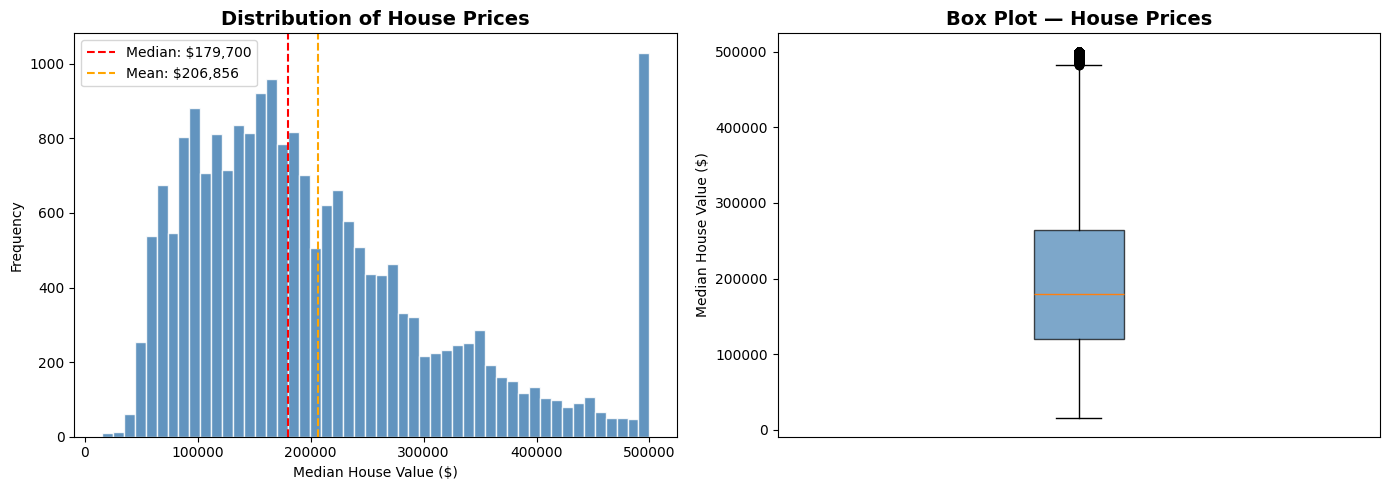

In [103]:
#Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['median_house_value'].median(), color='red', linestyle='--',
                label=f'Median: ${df["median_house_value"].median():,.0f}')
axes[0].axvline(df['median_house_value'].mean(), color='orange', linestyle='--',
                label=f'Mean: ${df["median_house_value"].mean():,.0f}')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['median_house_value'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot — House Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Median House Value ($)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Numeric columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_enc']


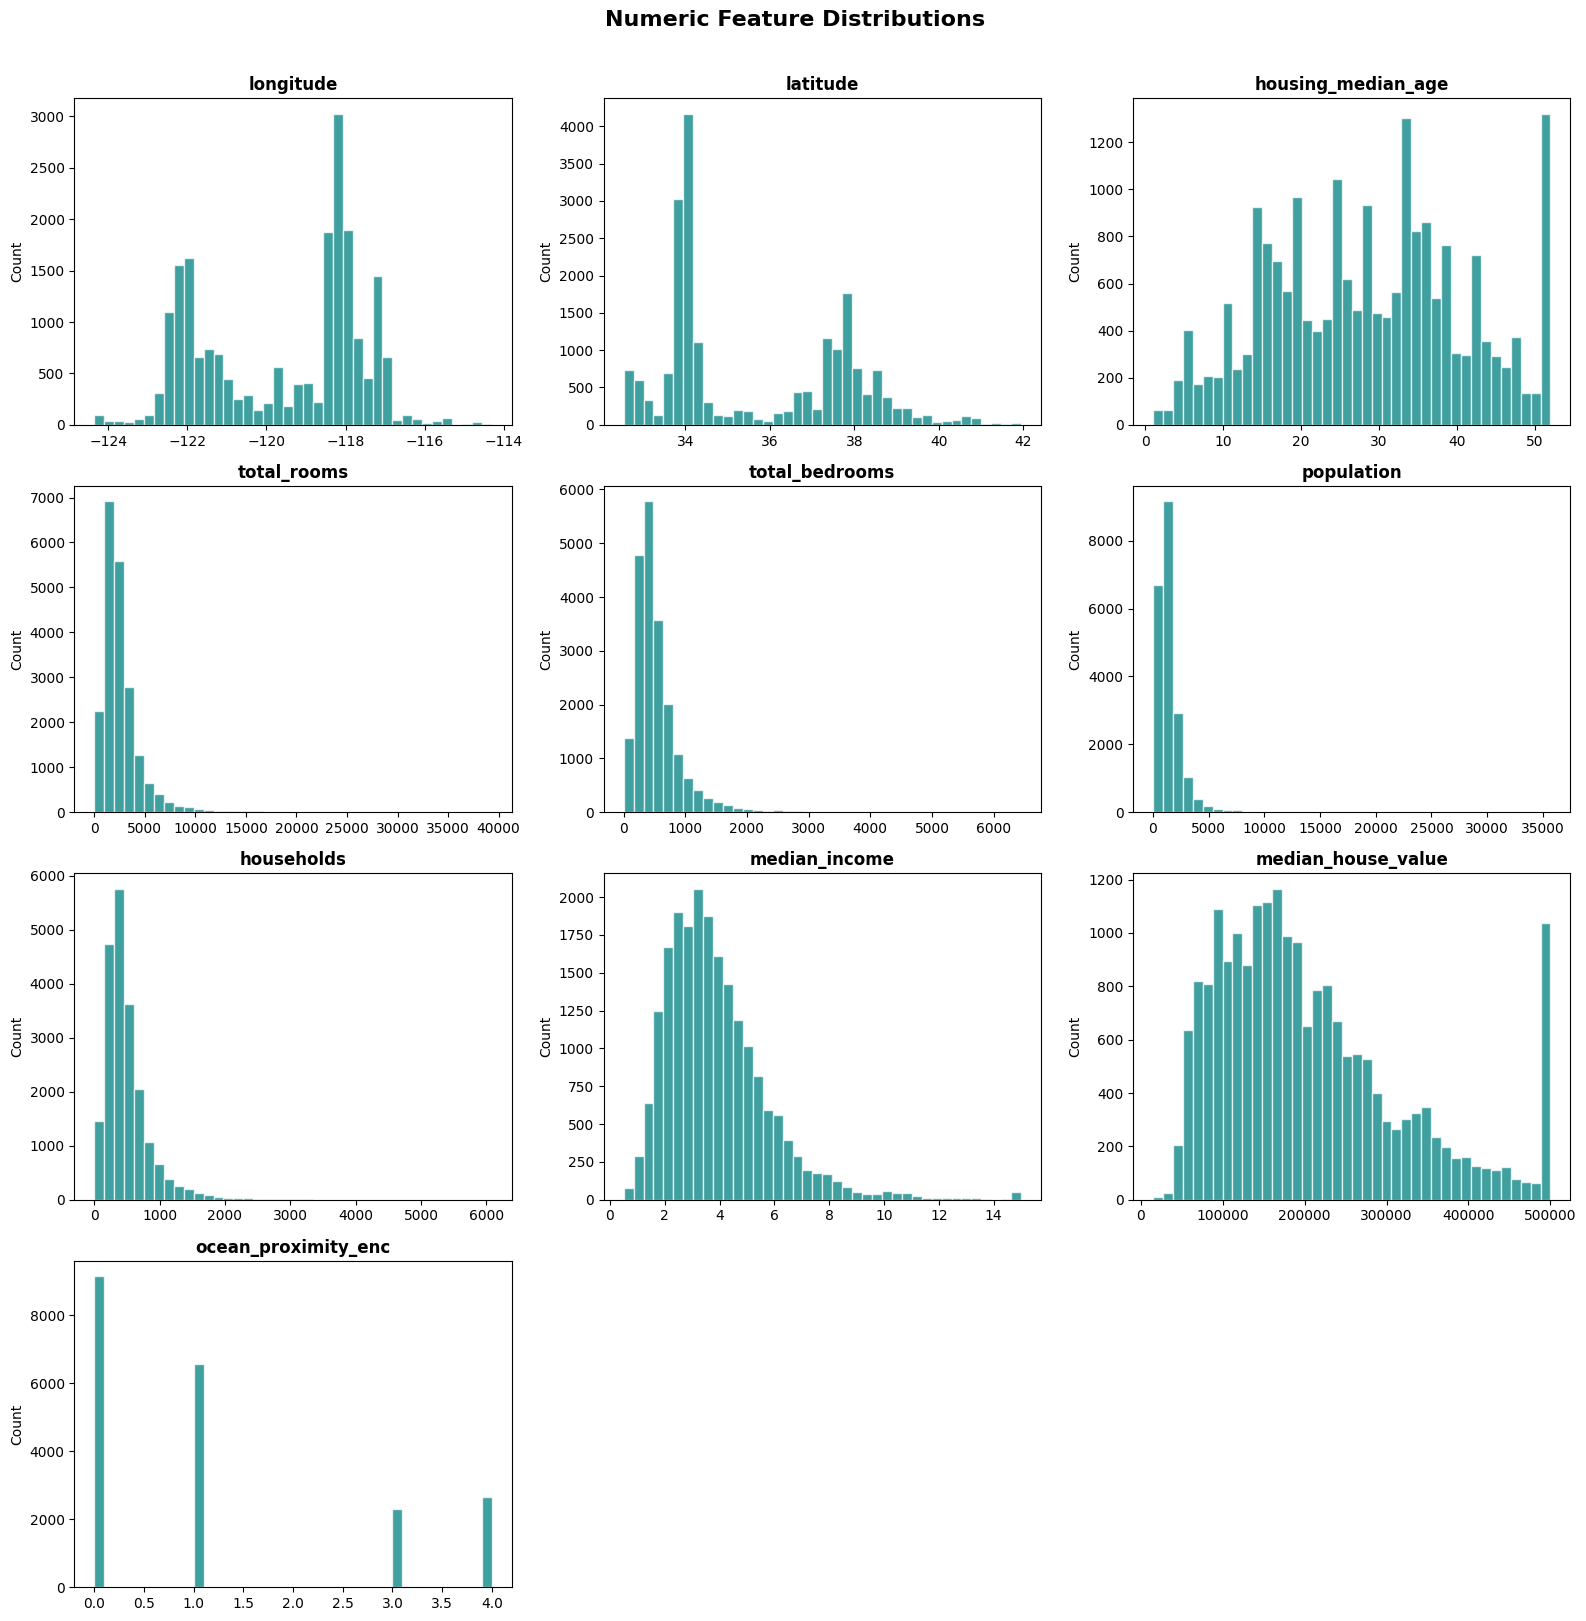

Saved: feature_distributions.png


In [130]:
#Numeric feature distributions
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns: {num_cols}')

n = len(num_cols)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='teal', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

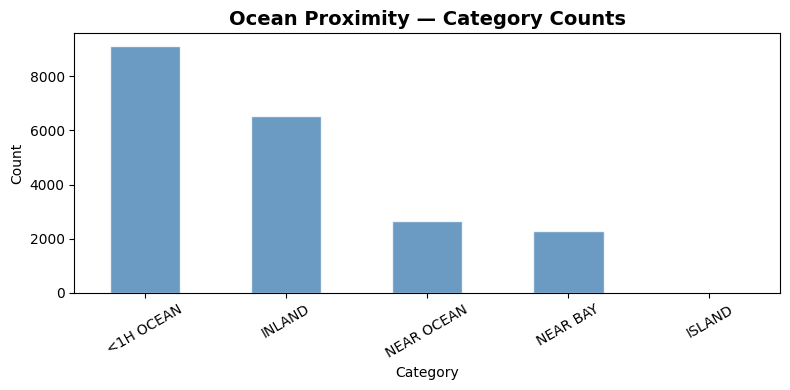

Saved: ocean_proximity.png


In [129]:
#ocean_proximity value counts
plt.figure(figsize=(8, 4))
df['ocean_proximity'].value_counts().plot(kind='bar', color='steelblue', alpha=0.8, edgecolor='white')
plt.title('Ocean Proximity — Category Counts', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ocean_proximity.png')

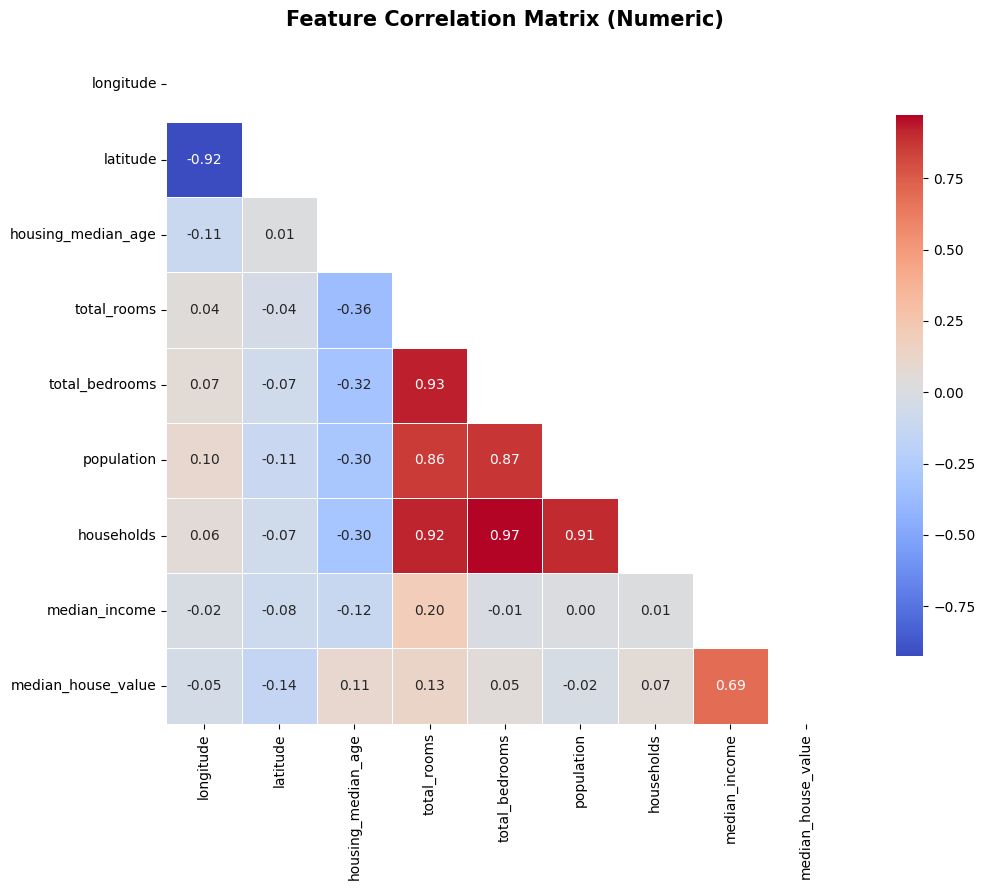

Saved: correlation_heatmap.png

=== Top Correlations with median_house_value ===
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160


In [128]:
#Correlation heatmap (numeric only)
plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()          # ← numeric cols only, no crash
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
plt.title('Feature Correlation Matrix (Numeric)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

print('\n=== Top Correlations with median_house_value ===')
print(corr['median_house_value'].drop('median_house_value').sort_values(ascending=False).to_string())

Top 4 correlated features: ['median_income', 'latitude', 'total_rooms', 'housing_median_age']


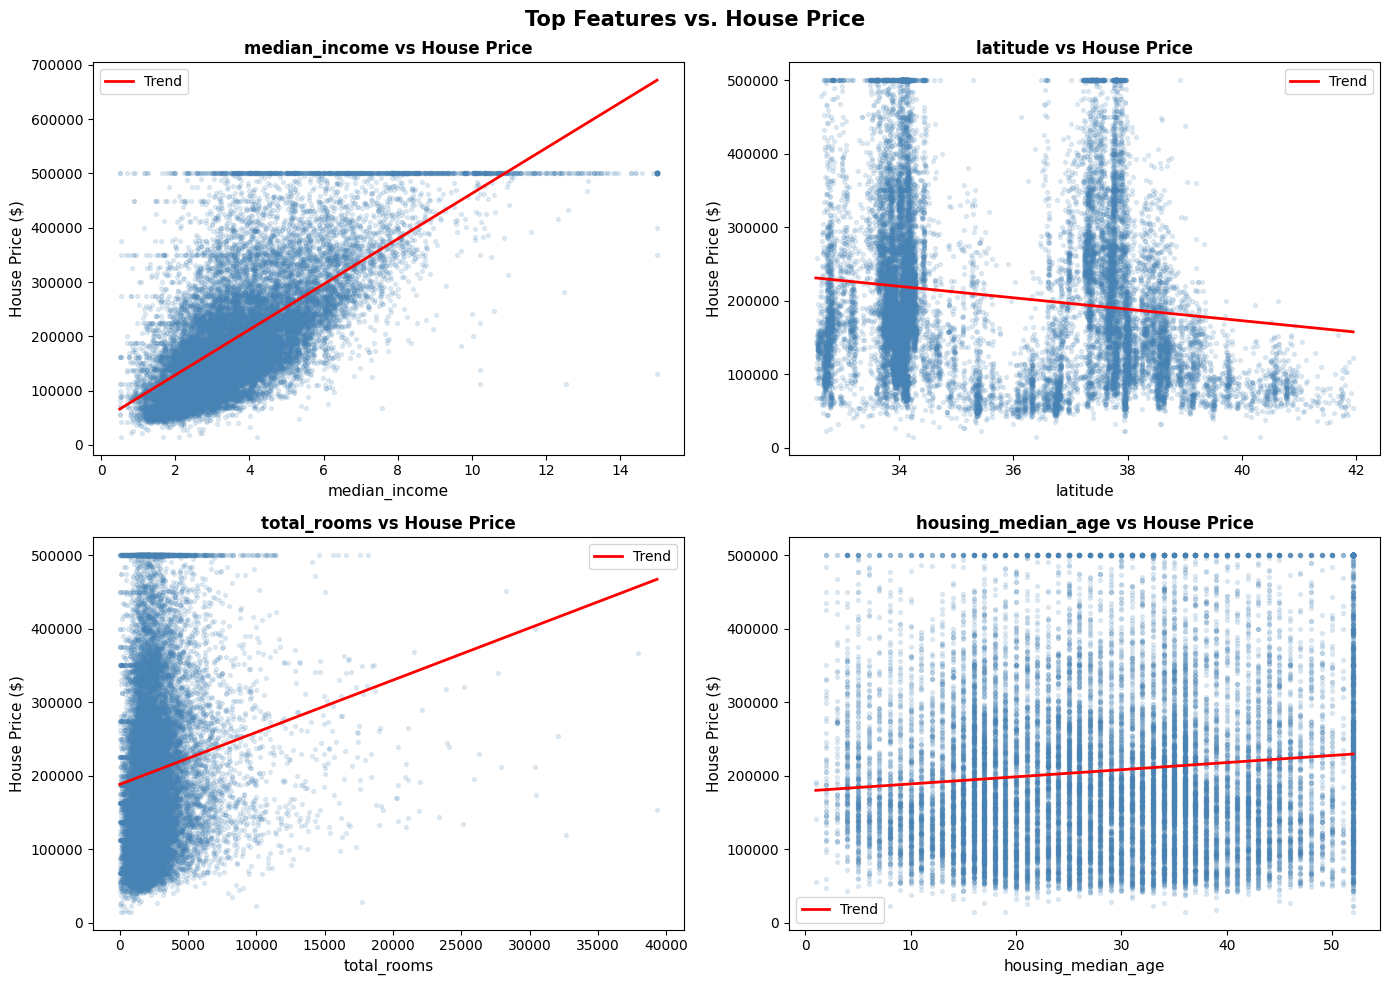

Saved: feature_scatter_plots.png


In [127]:
#Top features vs target scatter
top_feats = corr['median_house_value'].drop('median_house_value').abs().nlargest(4).index.tolist()
print(f'Top 4 correlated features: {top_feats}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(top_feats):
    clean = df[[feat, 'median_house_value']].dropna()
    axes[i].scatter(clean[feat], clean['median_house_value'], alpha=0.15, s=8, color='steelblue')
    m, b = np.polyfit(clean[feat], clean['median_house_value'], 1)
    xline = np.linspace(clean[feat].min(), clean[feat].max(), 100)
    axes[i].plot(xline, m*xline+b, color='red', linewidth=2, label='Trend')
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('House Price ($)', fontsize=11)
    axes[i].set_title(f'{feat} vs House Price', fontweight='bold')
    axes[i].legend()

plt.suptitle('Top Features vs. House Price', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_scatter_plots.png')

# STEP:4- Feature Selection&Train-Test Split

In [109]:
#Handle missing values (total_bedrooms → fill with median)
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
print(f'Missing after fill: {df.isnull().sum().sum()}')

#Encode ocean_proximity (Label Encoding)
df['ocean_proximity_enc'] = df['ocean_proximity'].astype('category').cat.codes
print(f'\nocean_proximity encoding:')
print(dict(zip(df['ocean_proximity'], df['ocean_proximity_enc'])))

Missing after fill: 0

ocean_proximity encoding:
{'NEAR BAY': 3, '<1H OCEAN': 0, 'INLAND': 1, 'NEAR OCEAN': 4, 'ISLAND': 2}


In [110]:
#Feature selection
feature_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                'total_bedrooms', 'population', 'households', 'median_income',
                'ocean_proximity_enc']
target_col   = 'median_house_value'

X = df[feature_cols]
y = df[target_col]

print(f'Features: {feature_cols}')
print(f'X shape : {X.shape}  |  y shape: {y.shape}')

Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_enc']
X shape : (20640, 9)  |  y shape: (20640,)


In [125]:
#Train / Test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training : {X_train.shape[0]:,} samples')
print(f'Test     : {X_test.shape[0]:,} samples')

# 4.5 — Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('\nStandardScaler applied.')

Training : 16,512 samples
Test     : 4,128 samples

StandardScaler applied.


# STEP:5- Train LinearRegression&Evaluate

In [124]:
# Train
model = LinearRegression()
model.fit(X_train_sc, y_train)
print(' Model trained!')

coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nFeature Coefficients (by magnitude):')
print(coef_df.to_string(index=False))

 Model trained!

Feature Coefficients (by magnitude):
            Feature   Coefficient
           latitude -90946.062711
          longitude -85854.947241
      median_income  77144.101642
     total_bedrooms  48767.606710
         population -43884.168524
        total_rooms -17693.234053
         households  17601.314951
 housing_median_age  14924.306551
ocean_proximity_enc   -451.520152


In [117]:
#Predict
y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

#Metrics
def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'  MAE  : ${mae:>10,.0f}')
    print(f'  RMSE : ${rmse:>10,.0f}')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, r2

tr_mae, tr_rmse, tr_r2 = metrics(y_train, y_pred_train, 'TRAIN SET')
print()
te_mae, te_rmse, te_r2 = metrics(y_test,  y_pred_test,  'TEST SET')

--- TRAIN SET ---
  MAE  : $    50,627
  RMSE : $    69,361
  R²   : 0.6401

--- TEST SET ---
  MAE  : $    51,821
  RMSE : $    71,148
  R²   : 0.6137


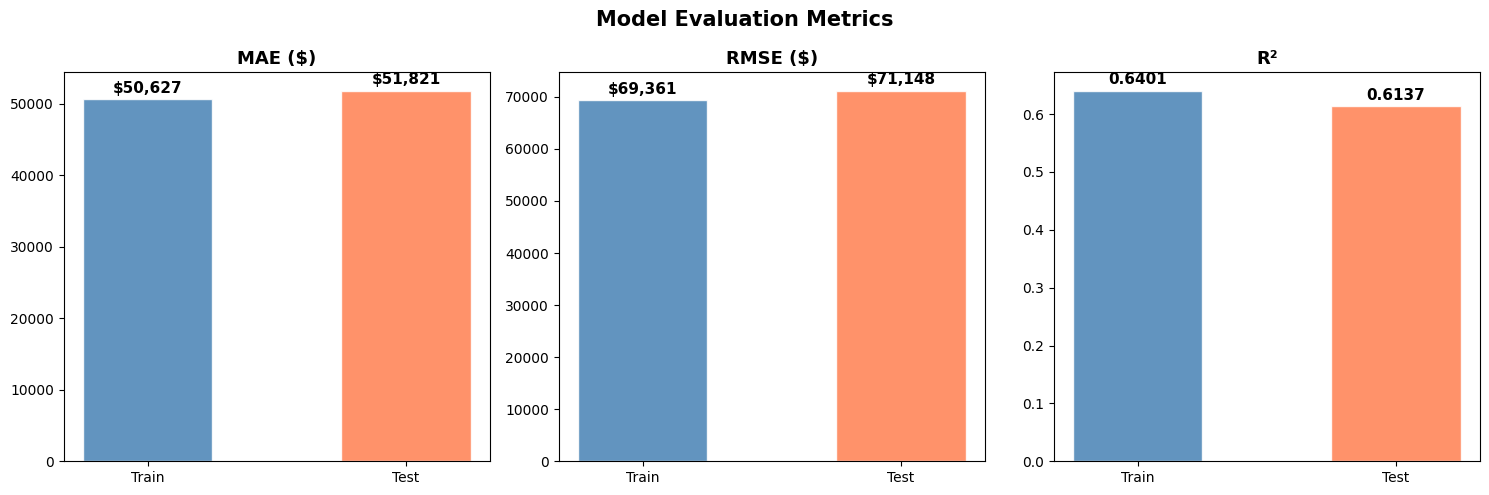

In [118]:
#Metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['MAE ($)', 'RMSE ($)', 'R²']
train_v = [tr_mae, tr_rmse, tr_r2]
test_v  = [te_mae, te_rmse, te_r2]
colors  = ['steelblue', 'coral']

for ax, lbl, tv, xv in zip(axes, labels, train_v, test_v):
    bars = ax.bar(['Train', 'Test'], [tv, xv], color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_title(lbl, fontsize=13, fontweight='bold')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01,
                f'${h:,.0f}' if '$' in lbl else f'{h:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


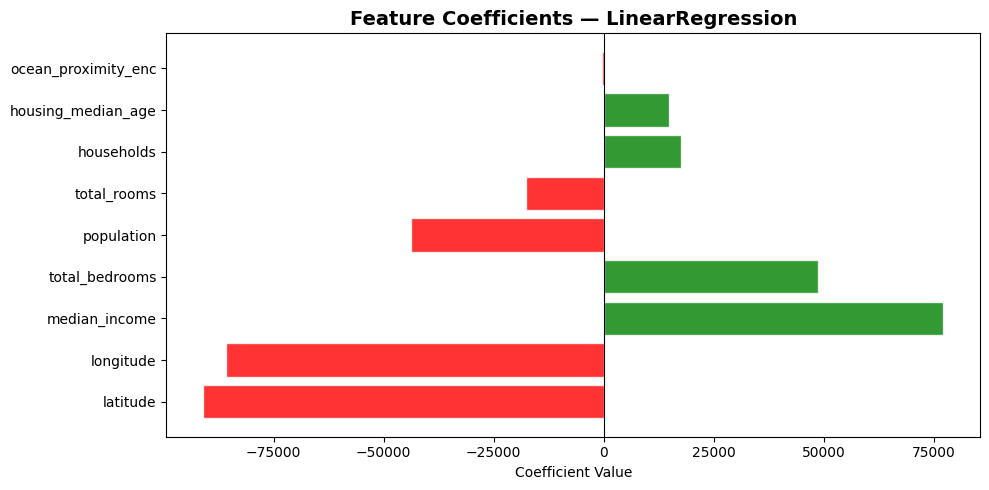

In [119]:
#Feature coefficient plot
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients — LinearRegression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


# **STEP:6- Predicted vs Actual & Residual Plots**

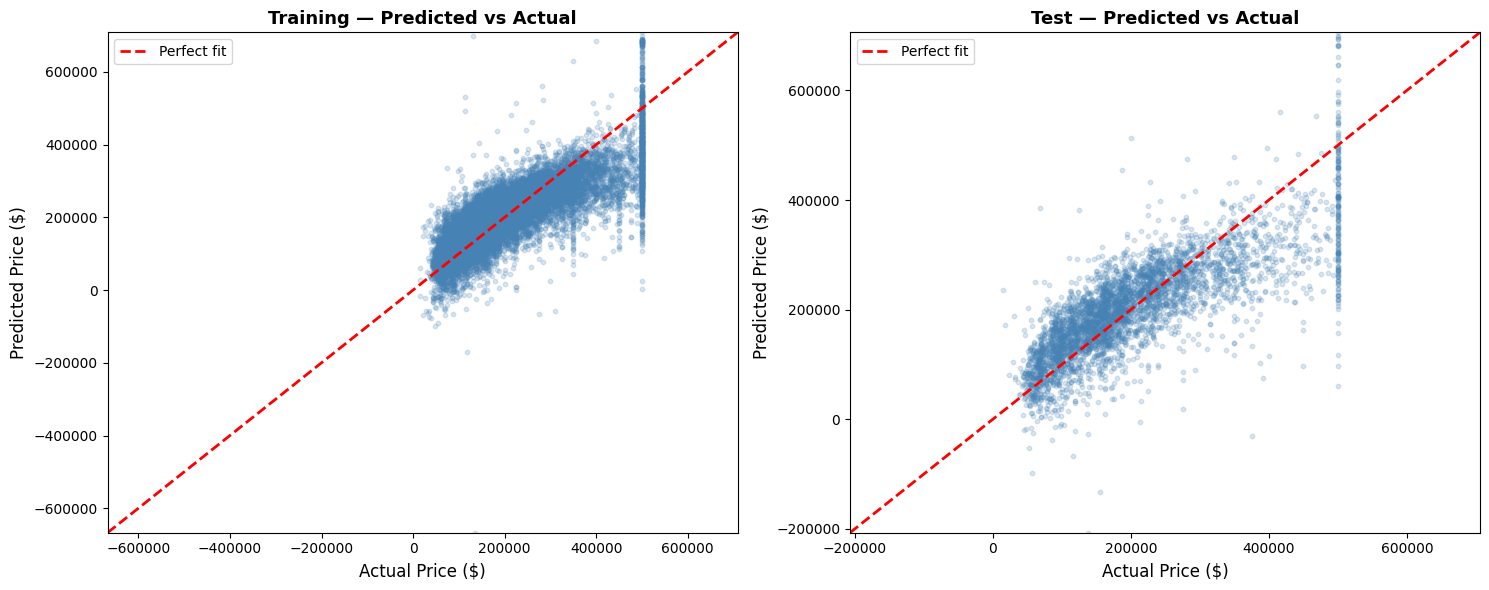

In [120]:
#Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, yt, yp, lbl in [
    (axes[0], y_train, y_pred_train, 'Training'),
    (axes[1], y_test,  y_pred_test,  'Test')
]:
    ax.scatter(yt, yp, alpha=0.2, s=10, color='steelblue')
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
    ax.set_xlabel('Actual Price ($)', fontsize=12)
    ax.set_ylabel('Predicted Price ($)', fontsize=12)
    ax.set_title(f'{lbl} — Predicted vs Actual', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

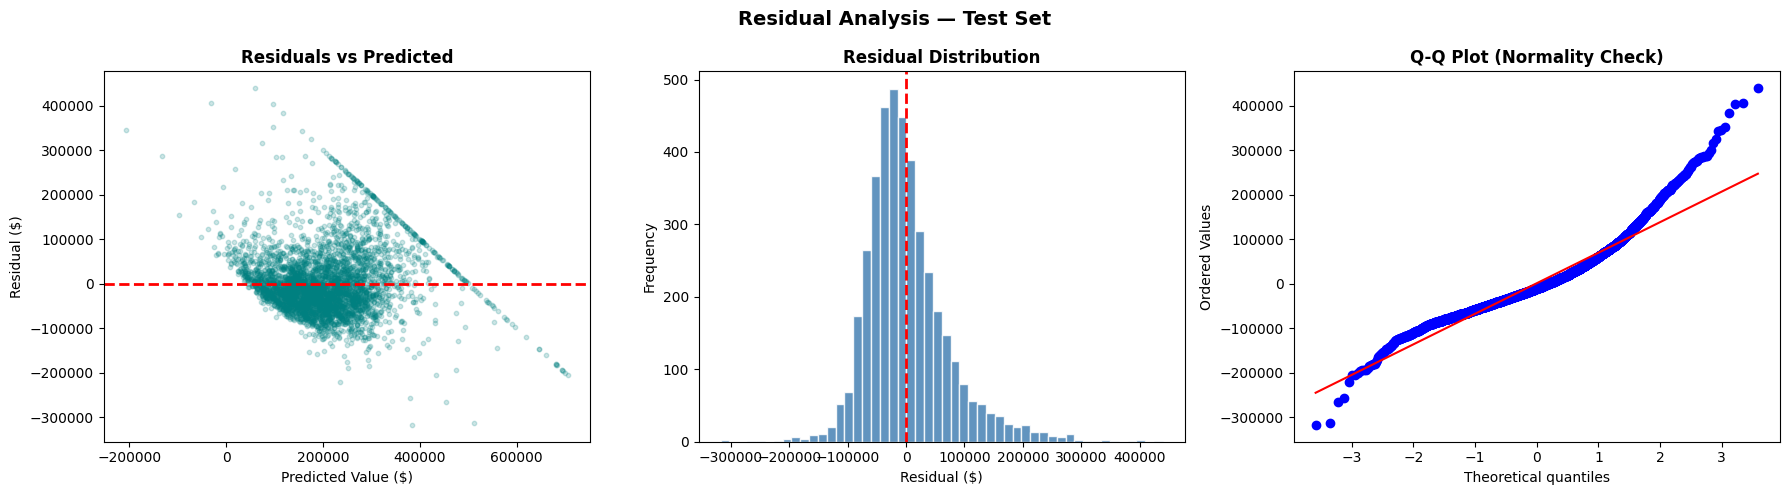

Saved: residual_analysis.png

Residual Mean  : $1,091  (ideal = $0)
Residual Std   : $71,140
Residual Skew  : 1.128


In [126]:
#Residual Analysis
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.2, s=10, color='teal')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Value ($)'); axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

# Residual histogram
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual ($)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontweight='bold')

plt.suptitle('Residual Analysis — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: residual_analysis.png')

print(f'\nResidual Mean  : ${residuals.mean():,.0f}  (ideal = $0)')
print(f'Residual Std   : ${residuals.std():,.0f}')
print(f'Residual Skew  : {stats.skew(residuals):.3f}')